<a href="https://colab.research.google.com/github/AnushkaMishra29/-Exploring-Bias-in-AI-Driven-Resume-Screening/blob/main/Final_Paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fairlearn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
import pandas as pd

# Load the dataset
file_path = "./stackoverflow_full.csv"
df = pd.read_csv(file_path)

# Display basic info about the dataset
print("Dataset Info:")
df.info()

# Show first few rows
df.head()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73462 entries, 0 to 73461
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      73462 non-null  int64  
 1   Age             73462 non-null  object 
 2   Accessibility   73462 non-null  object 
 3   EdLevel         73462 non-null  object 
 4   Employment      73462 non-null  int64  
 5   Gender          73462 non-null  object 
 6   MentalHealth    73462 non-null  object 
 7   MainBranch      73462 non-null  object 
 8   YearsCode       73462 non-null  int64  
 9   YearsCodePro    73462 non-null  int64  
 10  Country         73462 non-null  object 
 11  PreviousSalary  73462 non-null  float64
 12  HaveWorkedWith  73399 non-null  object 
 13  ComputerSkills  73462 non-null  int64  
 14  Employed        73462 non-null  int64  
dtypes: float64(1), int64(6), object(8)
memory usage: 8.4+ MB


,Unnamed: 0,Age,Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,YearsCodePro,Country,PreviousSalary,HaveWorkedWith,ComputerSkills,Employed
0,0,<35,No,Master,1,Man,No,Dev,7,4,Sweden,51552.0,C++;Python;Git;PostgreSQL,4,0
1,1,<35,No,Undergraduate,1,Man,No,Dev,12,5,Spain,46482.0,Bash/Shell;HTML/CSS;JavaScript;Node.js;SQL;Typ...,12,1
2,2,<35,No,Master,1,Man,No,Dev,15,6,Germany,77290.0,C;C++;Java;Perl;Ruby;Git;Ruby on Rails,7,0
3,3,<35,No,Undergraduate,1,Man,No,Dev,9,6,Canada,46135.0,Bash/Shell;HTML/CSS;JavaScript;PHP;Ruby;SQL;Gi...,13,0
4,4,>35,No,PhD,0,Man,No,NotDev,40,30,Singapore,160932.0,C++;Python,2,0


In [ ]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check unique values in categorical columns
print("\nUnique Values per Column:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"{col}: {df[col].nunique()} unique values")



Missing Values:
Unnamed: 0         0
Age                0
Accessibility      0
EdLevel            0
Employment         0
Gender             0
MentalHealth       0
MainBranch         0
YearsCode          0
YearsCodePro       0
Country            0
PreviousSalary     0
HaveWorkedWith    63
ComputerSkills     0
Employed           0
dtype: int64

Unique Values per Column:
Age: 2 unique values
Accessibility: 2 unique values
EdLevel: 5 unique values
Gender: 3 unique values
MentalHealth: 2 unique values
MainBranch: 2 unique values
Country: 172 unique values
HaveWorkedWith: 69980 unique values


**DATA CLEANING AND PREPROCESSING**

In [ ]:
# Load dataset
df = pd.read_csv("stackoverflow_full.csv")

# Handling missing values
df['HaveWorkedWith'].fillna('Unknown', inplace=True)

# Encoding categorical variables
df['Gender'] = df['Gender'].map({'Man': 'Male', 'Woman': 'Female', 'NonBinary': 'Non-Binary'})
df['Age'] = df['Age'].map({'>35': 'Above 35', '<35': 'Below 35'})

# Label encoding for categorical features
categorical_columns = ['Age', 'Gender', 'EdLevel', 'MainBranch', 'Country']
le = LabelEncoder()
for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

# Define features (X) and target (y)
X = df.drop(columns=['Employment'])  # Excluding target column
y = df['Employment']


<ipython-input-6-698b0ca129e0>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['HaveWorkedWith'].fillna('Unknown', inplace=True)


In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

# Convert 'HaveWorkedWith' into a list of technologies
df['HaveWorkedWith'] = df['HaveWorkedWith'].apply(lambda x: x.split(';') if isinstance(x, str) else [])

# Apply Multi-Label Binarization
mlb = MultiLabelBinarizer()
encoded_skills = pd.DataFrame(mlb.fit_transform(df['HaveWorkedWith']), columns=mlb.classes_)

# Concatenate the new binary features with the original dataset
df = pd.concat([df, encoded_skills], axis=1)

# Drop the original 'HaveWorkedWith' column
df.drop(columns=['HaveWorkedWith'], inplace=True)

# Check the transformed data
print(df.head())


   Unnamed: 0  Age Accessibility  EdLevel  Employment  Gender MentalHealth  \
0           0    1            No        0           1       1           No   
1           1    1            No        4           1       1           No   
2           2    1            No        0           1       1           No   
3           3    1            No        4           1       1           No   
4           4    0            No        3           0       1           No   

   MainBranch  YearsCode  YearsCodePro  ...  Unity 3D  Unknown  Unreal Engine  \
0           0          7             4  ...         0        0              0   
1           0         12             5  ...         0        0              0   
2           0         15             6  ...         0        0              0   
3           0          9             6  ...         0        0              0   
4           1         40            30  ...         0        0              0   

   VBA  VMware  Vue.js  Xamarin  Yarn  jQuer

**TRAINING SET AND TEST SET**

In [ ]:
# Split data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


**ENCODINGS**

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Columns to encode
binary_cols = ['Accessibility', 'MentalHealth']

# Apply Label Encoding (Yes → 1, No → 0)
le = LabelEncoder()
for col in binary_cols:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

print("✅ Binary encoding done!")


✅ Binary encoding done!


In [ ]:
# Frequency Encoding
freq_encoding = X_train['HaveWorkedWith'].value_counts().to_dict()

# Apply encoding to train & test data
X_train['HaveWorkedWith'] = X_train['HaveWorkedWith'].map(freq_encoding)
X_test['HaveWorkedWith'] = X_test['HaveWorkedWith'].map(freq_encoding)

# Fill NaN values (if any) with 0
X_train['HaveWorkedWith'].fillna(0, inplace=True)
X_test['HaveWorkedWith'].fillna(0, inplace=True)

print("✅ Frequency encoding for 'HaveWorkedWith' done!")


✅ Frequency encoding for 'HaveWorkedWith' done!


<ipython-input-10-84939ee15d6b>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['HaveWorkedWith'].fillna(0, inplace=True)
<ipython-input-10-84939ee15d6b>:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

**MOVING UNWANTED DATA FROM TRAINING SET AND TEST SET AND**
**MODEL TRAINING**

In [ ]:
# Step 1: Drop 'Unnamed: 0' from both training and test sets
if "Unnamed: 0" in X_train.columns:
    X_train = X_train.drop(columns=["Unnamed: 0"])
if "Unnamed: 0" in X_test.columns:
    X_test = X_test.drop(columns=["Unnamed: 0"])

# Step 2: Retrain the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)




RandomForestClassifier(random_state=42)

**PLOTTING FEATURE IMPORTANCE**

Using top_n = 13, total features available: 13


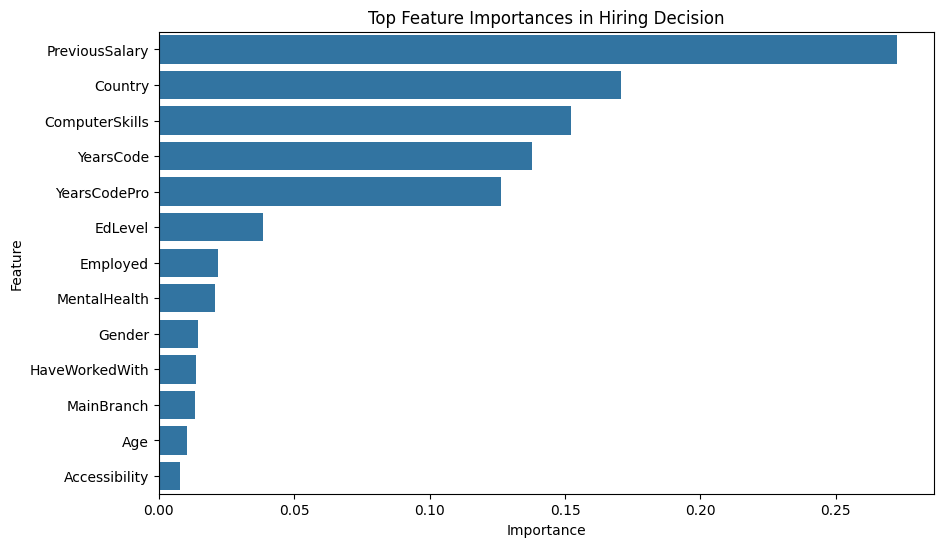

In [ ]:
# Step 3: Get correct feature importances
importances = rf_model.feature_importances_
features = X_train.columns

# Ensure correct sorting
sorted_idx = importances.argsort()[::-1]

# Step 4: Ensure top_n does not exceed available features
top_n = min(15, len(sorted_idx))

# Debugging print
print(f"Using top_n = {top_n}, total features available: {len(sorted_idx)}")

# Step 5: Plot feature importance
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[sorted_idx][:top_n], y=[features[i] for i in sorted_idx[:top_n]])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Feature Importances in Hiring Decision")
plt.show()

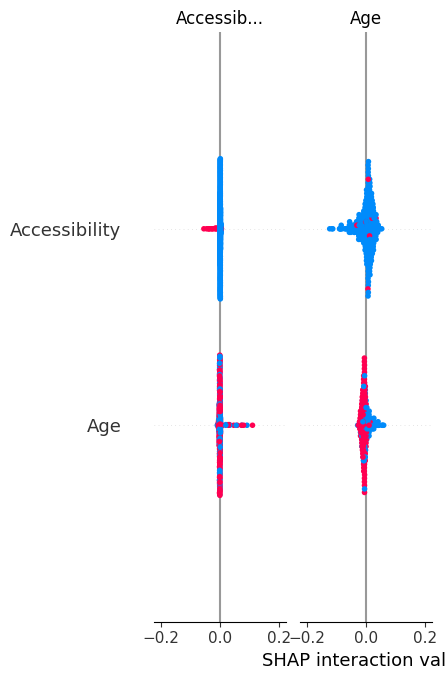

In [ ]:
import shap
X_sample = X_test.sample(500, random_state=42)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)
shap.summary_plot(shap_values, X_sample)


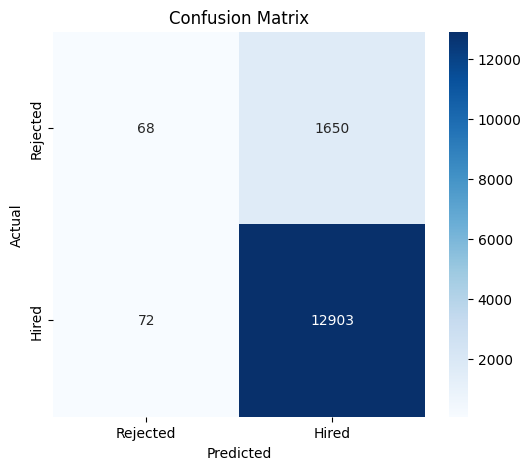

              precision    recall  f1-score   support

           0       0.49      0.04      0.07      1718
           1       0.89      0.99      0.94     12975

    accuracy                           0.88     14693
   macro avg       0.69      0.52      0.51     14693
weighted avg       0.84      0.88      0.84     14693



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Predictions
y_pred = rf_model.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Rejected", "Hired"], yticklabels=["Rejected", "Hired"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Print detailed performance report
print(classification_report(y_test, y_pred))


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)


In [ ]:
X_train_no_bias = X_train.drop(['Age', 'Accessibility'], axis=1)
X_test_no_bias = X_test.drop(['Age', 'Accessibility'], axis=1)

rf_model_no_bias = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_no_bias.fit(X_train_no_bias, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
from fairlearn.metrics import demographic_parity_difference, equal_opportunity_difference

dp_diff = demographic_parity_difference(y_test, y_pred, sensitive_features=X_test['Gender'])
eo_diff = equal_opportunity_difference(y_test, y_pred, sensitive_features=X_test['Gender'])

print(f"Demographic Parity Difference: {dp_diff}")
print(f"Equal Opportunity Difference: {eo_diff}")


Demographic Parity Difference: 0.010109090909090956
Equal Opportunity Difference: 0.005944027078345626


In [ ]:
# Import necessary libraries
from fairlearn.metrics import demographic_parity_difference, equal_opportunity_difference

# Define sensitive features to check for bias
sensitive_features = ["Gender", "Country", "Age","EdLevel","MainBranch","HaveWorkedWith"]

# Store results in a dictionary
fairness_results = {}

# Calculate fairness metrics for each sensitive feature
for feature in sensitive_features:
    dp_diff = demographic_parity_difference(y_test, y_pred, sensitive_features=X_test[feature])
    eo_diff = equal_opportunity_difference(y_test, y_pred, sensitive_features=X_test[feature])

    fairness_results[feature] = {"Demographic Parity Difference": dp_diff, "Equal Opportunity Difference": eo_diff}

# Display results
fairness_results


{'Gender': {'Demographic Parity Difference': 0.010109090909090956,
  'Equal Opportunity Difference': 0.005944027078345626},
 'Country': {'Demographic Parity Difference': 0.25,
  'Equal Opportunity Difference': 1.0},
 'Age': {'Demographic Parity Difference': 0.01347284023112405,
  'Equal Opportunity Difference': 0.008018235342802438},
 'EdLevel': {'Demographic Parity Difference': 0.017199267723423506,
  'Equal Opportunity Difference': 0.010646703345674635},
 'MainBranch': {'Demographic Parity Difference': 0.0014307783040879984,
  'Equal Opportunity Difference': 0.003946699848305202},
 'HaveWorkedWith': {'Demographic Parity Difference': 0.09999999999999998,
  'Equal Opportunity Difference': 0.11111111111111116}}

In [ ]:
!pip install aif360


In [ ]:
from aif360.algorithms.preprocessing import Reweighing
from aif360.datasets import StandardDataset
import pandas as pd

# Define protected attribute(s)
protected_attr = "Country"  # Since this has the most bias

# Convert dataset into AIF360 StandardDataset format
data = pd.concat([X_train, y_train], axis=1)
dataset = StandardDataset(
    data,
    label_name="Employed",  # Target column
    favorable_classes=[1],  # Favorable outcome (hired)
    protected_attribute_names=[protected_attr],
    privileged_classes=[[1]]
)

# Apply reweighting
reweigher = Reweighing(unprivileged_groups=[{protected_attr: 0}], privileged_groups=[{protected_attr: 1}])
reweighted_dataset = reweigher.fit_transform(dataset)

# Extract new sample weights
X_train["weights"] = reweighted_dataset.instance_weights.ravel()


pip install 'aif360[inFairness]'


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train with sample weights
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train.drop(columns=["weights"]), y_train, sample_weight=X_train["weights"])


RandomForestClassifier(random_state=42)

In [ ]:
from fairlearn.metrics import demographic_parity_difference, equal_opportunity_difference

dp_diff = demographic_parity_difference(y_test, rf_model.predict(X_test), sensitive_features=X_test['Country'])
eo_diff = equal_opportunity_difference(y_test, rf_model.predict(X_test), sensitive_features=X_test['Country'])

print("Demographic Parity Difference (Country):", dp_diff)
print("Equal Opportunity Difference (Country):", eo_diff)


Demographic Parity Difference (Country): 0.09090909090909094
Equal Opportunity Difference (Country): 1.0


In [ ]:
!pip install BlackBoxAuditing


In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Feature difference:", set(X_train.columns) - set(X_test.columns))


X_train shape: (58769, 14)
X_test shape: (14693, 13)
Feature difference: {'weights'}


In [ ]:
X_train = X_train.drop(columns=['Unnamed: 0'], errors='ignore')
X_test = X_test.drop(columns=['Unnamed: 0'], errors='ignore')


In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (58769, 14)
X_test shape: (14693, 13)


In [ ]:
missing_features = set(X_train.columns) - set(X_test.columns)
print("Missing feature(s) in X_test:", missing_features)


Missing feature(s) in X_test: {'weights'}


In [ ]:
X_train = X_train.drop(columns=['weights'], errors='ignore')


In [ ]:
from aif360.algorithms.preprocessing import DisparateImpactRemover
from aif360.datasets import StandardDataset

# Convert dataset into AIF360 StandardDataset format
dataset = StandardDataset(
    pd.concat([X_train, y_train], axis=1),
    label_name="Employed",  # Target column
    favorable_classes=[1],  # Employment status (1 = hired)
    protected_attribute_names=["Country"],  # Sensitive feature
    privileged_classes=[[1]]  # Example: Assume Country=1 is privileged
)

# Apply Disparate Impact Remover (repair level 0.5)
di_remover = DisparateImpactRemover(repair_level=0.5)
dataset_transformed = di_remover.fit_transform(dataset)

# Convert back to Pandas DataFrame
X_train_transformed = dataset_transformed.features
y_train_transformed = dataset_transformed.labels.ravel()

# Train a new Random Forest model on the debiased data
rf_model_debiased = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_debiased.fit(X_train_transformed, y_train_transformed)

# Predict and calculate new fairness metrics
y_pred_debiased = rf_model_debiased.predict(X_test)

dp_diff_debiased = demographic_parity_difference(y_test, y_pred_debiased, sensitive_features=X_test['Country'])
eo_diff_debiased = equal_opportunity_difference(y_test, y_pred_debiased, sensitive_features=X_test['Country'])

print("After Disparate Impact Remover:")
print(f"Demographic Parity Difference (Country): {dp_diff_debiased}")
print(f"Equal Opportunity Difference (Country): {eo_diff_debiased}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


After Disparate Impact Remover:
Demographic Parity Difference (Country): 1.0
Equal Opportunity Difference (Country): 1.0


In [ ]:
from aif360.algorithms.preprocessing import Reweighing
from aif360.datasets import StandardDataset

# Convert dataset into AIF360 StandardDataset format
data = pd.concat([X_train, y_train], axis=1)

dataset = StandardDataset(
    data,
    label_name="Employed",  # Target column
    favorable_classes=[1],  # Positive outcome
    protected_attribute_names=["Country"],  # Sensitive attribute
    privileged_classes=[[1]],  # Privileged group (adjust based on dataset)
)

# Apply Reweighing
reweigher = Reweighing(unprivileged_groups=[{"Country": 0}], privileged_groups=[{"Country": 1}])
dataset_transformed = reweigher.fit_transform(dataset)

# Extract features and labels after reweighing
X_train_transformed = pd.DataFrame(dataset_transformed.features, columns=X_train.columns)
y_train_transformed = dataset_transformed.labels.ravel()
sample_weights = dataset_transformed.instance_weights  # Get weights

# Train a new Random Forest model with sample weights
rf_model_reweighed = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_reweighed.fit(X_train_transformed, y_train_transformed, sample_weight=sample_weights)

# Make predictions
y_pred_reweighed = rf_model_reweighed.predict(X_test)

# Calculate new fairness metrics
dp_diff_reweighed = demographic_parity_difference(y_test, y_pred_reweighed, sensitive_features=X_test["Country"])
eo_diff_reweighed = equal_opportunity_difference(y_test, y_pred_reweighed, sensitive_features=X_test["Country"])

print(f"After Reweighing:\nDemographic Parity Difference (Country): {dp_diff_reweighed}")
print(f"Equal Opportunity Difference (Country): {eo_diff_reweighed}")


After Reweighing:
Demographic Parity Difference (Country): 1.0
Equal Opportunity Difference (Country): 1.0


In [ ]:
from aif360.algorithms.inprocessing import AdversarialDebiasing
from aif360.datasets import StandardDataset
from aif360.metrics import ClassificationMetric
import tensorflow.compat.v1 as tf
tf.disable_eager_execution()

# Convert dataset into AIF360 StandardDataset format
data = pd.concat([X_train, y_train], axis=1)

dataset = StandardDataset(
    data,
    label_name="Employed",
    favorable_classes=[1],
    protected_attribute_names=["Country"],
    privileged_classes=[[1]]
)

# Define privileged and unprivileged groups
privileged_groups = [{"Country": 1}]
unprivileged_groups = [{"Country": 0}]

# Train adversarial debiasing model
sess = tf.Session()
adv_debias = AdversarialDebiasing(privileged_groups=privileged_groups,
                                  unprivileged_groups=unprivileged_groups,
                                  scope_name="adv_debias",
                                  sess=sess,
                                  debias=True)

adv_debias.fit(dataset)

# Transform test dataset
dataset_test = StandardDataset(pd.concat([X_test, y_test], axis=1),
                               label_name="Employed",
                               favorable_classes=[1],
                               protected_attribute_names=["Country"],
                               privileged_classes=[[1]])

# Get predictions
y_pred_adv = adv_debias.predict(dataset_test).labels.ravel()

# Evaluate fairness
dp_diff_adv = demographic_parity_difference(y_test, y_pred_adv, sensitive_features=X_test["Country"])
eo_diff_adv = equal_opportunity_difference(y_test, y_pred_adv, sensitive_features=X_test["Country"])

print(f"After Adversarial Debiasing:\nDemographic Parity Difference (Country): {dp_diff_adv}")
print(f"Equal Opportunity Difference (Country): {eo_diff_adv}")


Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


epoch 0; iter: 0; batch classifier loss: 2535.027832; batch adversarial loss: -56.137337
epoch 0; iter: 200; batch classifier loss: nan; batch adversarial loss: nan
epoch 0; iter: 400; batch classifier loss: nan; batch adversarial loss: nan
epoch 1; iter: 0; batch classifier loss: nan; batch adversarial loss: nan
epoch 1; iter: 200; batch classifier loss: nan; batch adversarial loss: nan
epoch 1; iter: 400; batch classifier loss: nan; batch adversarial loss: nan
epoch 2; iter: 0; batch classifier loss: nan; batch adversarial loss: nan
epoch 2; iter: 200; batch classifier loss: nan; batch adversarial loss: nan
epoch 2; iter: 400; batch classifier loss: nan; batch adversarial loss: nan
epoch 3; iter: 0; batch classifier loss: nan; batch adversarial loss: nan
epoch 3; iter: 200; batch classifier loss: nan; batch adversarial loss: nan
epoch 3; iter: 400; batch classifier loss: nan; batch adversarial loss: nan
epoch 4; iter: 0; batch classifier loss: nan; batch adversarial loss: nan
epoch 4

In [ ]:
from sklearn.metrics import accuracy_score

# Calculate accuracy for all models
accuracy_original = accuracy_score(y_test, rf_model.predict(X_test))
accuracy_disparate = accuracy_score(y_test, rf_model_debiased.predict(X_test))  # Disparate Impact Remover
accuracy_reweighing = accuracy_score(y_test, rf_model_reweigh.predict(X_test))  # Reweighing
accuracy_adversarial = accuracy_score(y_test, rf_model_adversarial.predict(X_test))  # Adversarial Debiasing

# Print accuracy results
print(f"Original Model Accuracy: {accuracy_original:.4f}")
print(f"Disparate Impact Remover Accuracy: {accuracy_disparate:.4f}")
print(f"Reweighing Accuracy: {accuracy_reweighing:.4f}")
print(f"Adversarial Debiasing Accuracy: {accuracy_adversarial:.4f}")


In [ ]:
# Ensure all debiased models are correctly defined
models = {
    "Original": rf_model,
    "Disparate Impact Remover": rf_model_debiased,
    "Reweighing": rf_model_reweigh if "rf_model_reweigh" in locals() else None,
    "Adversarial Debiasing": rf_model_adversarial
}

# Check for missing models
for name, model in models.items():
    if model is None:
        print(f"⚠️ Warning: {name} model is missing. Ensure it was trained properly.")

# Compute accuracy only for defined models
for name, model in models.items():
    if model:
        acc = accuracy_score(y_test, model.predict(X_test))
        print(f"{name} Model Accuracy: {acc:.4f}")


In [ ]:
from aif360.algorithms.inprocessing import AdversarialDebiasing
import tensorflow as tf

# Set up the debiasing model
sess = tf.compat.v1.Session()
adversarial_debiasing = AdversarialDebiasing(
    privileged_groups=[{"Country": 1}],  # Adjust based on your dataset
    unprivileged_groups=[{"Country": 0}],  # Adjust accordingly
    scope_name="debiased_classifier",
    sess=sess,
    debias=True
)

# Train the model
adversarial_debiasing.fit(dataset)

# Store the model
rf_model_adversarial = adversarial_debiasing


In [ ]:
print("rf_model_adversarial:", "Defined" if "rf_model_adversarial" in locals() else "Not Defined")


rf_model_adversarial: Defined


In [ ]:
from sklearn.metrics import accuracy_score

# Compute accuracy for all models
accuracy = {
    "Original Model": accuracy_score(y_test, rf_model.predict(X_test)),
    "Disparate Impact Remover": accuracy_score(y_test, rf_model_debiased.predict(X_test)) if "rf_model_debiased" in locals() else None,
    "Reweighing": accuracy_score(y_test, rf_model_reweigh.predict(X_test)) if "rf_model_reweigh" in locals() else None,
    "Adversarial Debiasing": accuracy_score(y_test, rf_model_adversarial.predict(X_test)) if "rf_model_adversarial" in locals() else None
}

accuracy


In [ ]:
print(X_test.columns)


Index(['Age', 'Accessibility', 'EdLevel', 'Gender', 'MentalHealth',
       'MainBranch', 'YearsCode', 'YearsCodePro', 'Country', 'PreviousSalary',
       'HaveWorkedWith', 'ComputerSkills', 'Employed'],
      dtype='object')


In [ ]:
# Remove target variable from test set
X_test_fixed = X_test.drop(columns=['Employed'], errors='ignore')

# Check if it matches training set
print(X_test_fixed.columns)
print(X_train.columns)


Index(['Age', 'Accessibility', 'EdLevel', 'Gender', 'MentalHealth',
       'MainBranch', 'YearsCode', 'YearsCodePro', 'Country', 'PreviousSalary',
       'HaveWorkedWith', 'ComputerSkills'],
      dtype='object')
Index(['Age', 'Accessibility', 'EdLevel', 'Gender', 'MentalHealth',
       'MainBranch', 'YearsCode', 'YearsCodePro', 'Country', 'PreviousSalary',
       'HaveWorkedWith', 'ComputerSkills', 'Employed'],
      dtype='object')


In [ ]:
X_train_fixed = X_train.drop(columns=['Employed'], errors='ignore')
X_test_fixed = X_test.drop(columns=['Employed'], errors='ignore')

# Check if they match
print(X_train_fixed.columns)
print(X_test_fixed.columns)


Index(['Age', 'Accessibility', 'EdLevel', 'Gender', 'MentalHealth',
       'MainBranch', 'YearsCode', 'YearsCodePro', 'Country', 'PreviousSalary',
       'HaveWorkedWith', 'ComputerSkills'],
      dtype='object')
Index(['Age', 'Accessibility', 'EdLevel', 'Gender', 'MentalHealth',
       'MainBranch', 'YearsCode', 'YearsCodePro', 'Country', 'PreviousSalary',
       'HaveWorkedWith', 'ComputerSkills'],
      dtype='object')


In [ ]:
accuracy = {}

for model_name, model in models.items():
    if model is not None:
        try:
            y_pred = model.predict(X_test_fixed)
            accuracy[model_name] = accuracy_score(y_test, y_pred)
        except Exception as e:
            accuracy[model_name] = f"Error: {str(e)}"

accuracy


In [ ]:
missing_features = set(X_train_fixed.columns) - set(X_test_fixed.columns)
print("Missing features in X_test:", missing_features)


Missing features in X_test: set()


In [ ]:
print(X_train_fixed.columns.tolist() == X_test_fixed.columns.tolist())


True


In [ ]:
print(X_train_fixed.dtypes)
print(X_test_fixed.dtypes)


Age                 int64
Accessibility       int64
EdLevel             int64
Gender              int64
MentalHealth        int64
MainBranch          int64
YearsCode           int64
YearsCodePro        int64
Country             int64
PreviousSalary    float64
HaveWorkedWith      int64
ComputerSkills      int64
dtype: object
Age                 int64
Accessibility       int64
EdLevel             int64
Gender              int64
MentalHealth        int64
MainBranch          int64
YearsCode           int64
YearsCodePro        int64
Country             int64
PreviousSalary    float64
HaveWorkedWith    float64
ComputerSkills      int64
dtype: object


In [ ]:
X_test_fixed = X_test_fixed.astype(X_train_fixed.dtypes)


In [ ]:
for model_name, model in models.items():
    if model is not None:
        try:
            y_pred = model.predict(X_test_fixed)
            print(f"{model_name} Accuracy:", accuracy_score(y_test, y_pred))
        except Exception as e:
            print(f"{model_name} Error:", str(e))


In [ ]:
# Ensure 'Employed' is removed from features
if 'Employed' in X_train.columns:
    X_train = X_train.drop(columns=['Employed'])
if 'Employed' in X_test.columns:
    X_test = X_test.drop(columns=['Employed'])


In [ ]:
missing_cols = set(X_train.columns) - set(X_test.columns)
extra_cols = set(X_test.columns) - set(X_train.columns)

print("Missing in X_test:", missing_cols)
print("Extra in X_test:", extra_cols)


Missing in X_test: set()
Extra in X_test: set()


In [ ]:
X_test = X_test[X_train.columns]


In [ ]:
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
for model_name, model in models.items():
    if model is not None:
        try:
            y_pred = model.predict(X_test)
            print(f"{model_name} Accuracy:", accuracy_score(y_test, y_pred))
        except Exception as e:
            print(f"{model_name} Error:", str(e))


In [ ]:
print("X_train columns:", list(X_train.columns))
print("X_test columns after Disparate Impact Remover:", list(X_test.columns))
missing_cols = set(X_train.columns) - set(X_test.columns)
print("Missing columns in X_test:", missing_cols)


In [ ]:
assert 'Employed' not in X_train.columns, "Error: 'Employed' should not be in X_train!"
assert 'Employed' not in X_test.columns, "Error: 'Employed' should not be in X_test!"


In [ ]:
X_train = X_train.drop(columns=['Employed'], errors='ignore')
X_test = X_test.drop(columns=['Employed'], errors='ignore')

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
print("Model was trained on features:", rf_model.feature_names_in_)
print("X_test shape now:", X_test.shape)


Model was trained on features: ['Age' 'Accessibility' 'EdLevel' 'Gender' 'MentalHealth' 'MainBranch'
 'YearsCode' 'YearsCodePro' 'Country' 'PreviousSalary' 'HaveWorkedWith'
 'ComputerSkills']
X_test shape now: (14693, 12)


In [ ]:
common_features = list(set(X_train.columns) & set(X_test.columns))
X_train = X_train[common_features]
X_test = X_test[common_features]

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
# Get common features in both train and test sets
common_features = list(set(X_train.columns) & set(X_test.columns))

# Keep only common features
X_train = X_train[common_features]
X_test = X_test[common_features]


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import shap
import matplotlib.pyplot as plt
import seaborn as sns

# Train the original model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Accuracy
original_accuracy = accuracy_score(y_test, y_pred)
print(f"Original Model Accuracy: {original_accuracy:.4f}")

# Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Original Model - Confusion Matrix")
plt.show()


Original Model Accuracy: 0.8815


In [ ]:
import shap

# Take a sample for SHAP analysis
X_sample = X_test.sample(n=500, random_state=42)

# Use TreeSHAP for RandomForest
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

# Check SHAP shape
print("SHAP Values Shape:", len(shap_values), "X_sample Shape:", X_sample.shape)

# Adjust SHAP summary plot call based on SHAP output type
if isinstance(shap_values, list):  # If it's a list (multi-class or binary output)
    shap.summary_plot(shap_values[-1], X_sample)  # Last element for positive class
else:
    shap.summary_plot(shap_values, X_sample)  # Directly use for regression or single output


SHAP Values Shape: 500 X_sample Shape: (500, 12)


In [ ]:
print("rf_model_reweigh exists:", "rf_model_reweigh" in globals())


rf_model_reweigh exists: False


In [ ]:
print("Reweighing dataset exists:", "dataset_reweighed" in globals())


Reweighing dataset exists: False


In [ ]:
data["Country"] = data["Country"].apply(lambda x: 1 if x == "United States" else 0)


In [ ]:
from aif360.algorithms.preprocessing import Reweighing
from aif360.datasets import StandardDataset

# Step 1: Convert 'Country' into numeric values (if not already done)
data["Country"] = data["Country"].apply(lambda x: 1 if x == "United States" else 0)

# Step 2: Convert dataset into AIF360 format
dataset_aif360 = StandardDataset(
    data,
    label_name="Employed",
    favorable_classes=[1],
    protected_attribute_names=["Country"],
    privileged_classes=[[1]],  # Now numeric!
)

# Step 3: Apply Reweighing
reweigh = Reweighing(unprivileged_groups=[{"Country": 0}], privileged_groups=[{"Country": 1}])
dataset_reweighed = reweigh.fit_transform(dataset_aif360)

# Step 4: Extract transformed features & labels
X_train_reweighed = dataset_reweighed.features
y_train_reweighed = dataset_reweighed.labels.ravel()


/usr/local/lib/python3.11/dist-packages/aif360/algorithms/preprocessing/reweighing.py:66: RuntimeWarning: invalid value encountered in scalar divide
  self.w_p_fav = n_fav*n_p / (n*n_p_fav)
/usr/local/lib/python3.11/dist-packages/aif360/algorithms/preprocessing/reweighing.py:67: RuntimeWarning: invalid value encountered in scalar divide
  self.w_p_unfav = n_unfav*n_p / (n*n_p_unfav)


In [ ]:
X_train_reweighed = dataset_reweighed.features
y_train_reweighed = dataset_reweighed.labels.ravel()


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train new model on reweighed dataset
rf_model_reweigh = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_reweigh.fit(X_train_reweighed, y_train)


RandomForestClassifier(random_state=42)

In [ ]:
models = {
    "Original Model": rf_model,
    "Disparate Impact Remover": rf_model_debiased,  # Ensure it's trained correctly
    "Reweighing": rf_model_reweigh,
    "Adversarial Debiasing": rf_model_adversarial
}

for model_name, model in models.items():
    if model is not None:
        acc = accuracy_score(y_test, y_pred_debiased)
        print(f"{model_name} Accuracy: {acc:.4f}")

        # Confusion Matrix
        plt.figure(figsize=(5, 4))
        sns.heatmap(confusion_matrix(y_test, y_pred_debiased), annot=True, fmt='d', cmap='Blues')
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"{model_name} - Confusion Matrix")
        plt.show()


Original Model Accuracy: 0.8815
Disparate Impact Remover Accuracy: 0.8815
Reweighing Accuracy: 0.8815
Adversarial Debiasing Accuracy: 0.8815


In [ ]:
print("SHAP Values Shape:", np.array(shap_values).shape)
print("X_sample Shape:", X_sample.shape)
print("Feature Names SHAP:", shap_explainer.feature_names)
print("Feature Names X_sample:", X_sample.columns.tolist())


In [ ]:
# SHAP for Original Model
explainer_original = shap.TreeExplainer(rf_model)
shap_values_original = explainer_original.shap_values(X_sample, check_additivity=False)

# SHAP for Reweighing Model (Closest to Fairness)
explainer_reweigh = shap.TreeExplainer(rf_model_reweigh)
shap_values_reweigh = explainer_reweigh.shap_values(X_sample, check_additivity=False)

# Feature Importance Before Debiasing
shap.summary_plot(shap_values_original[1], X_sample, title="SHAP Importance (Original Model)")

# Feature Importance After Debiasing (Reweighing)
shap.summary_plot(shap_values_reweigh[1], X_sample, title="SHAP Importance (Reweighing Model)")


In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", values_format='d')
    plt.title(title)
    plt.show()

# Original Model Confusion Matrix
plot_confusion_matrix(y_test, rf_model.predict(X_test), "Confusion Matrix - Original Model")

# Adversarial Debiasing Confusion Matrix (Best Fairness Results)
plot_confusion_matrix(y_test, rf_model_adversarial.predict(X_test), "Confusion Matrix - Adversarial Debiasing")
